# API调用

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(
    solver="sag",
    multi_class="multinomial",
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    penalty='l1',
    C=0.1
)

# 心脏病案例-逻辑回归

In [1]:
# 1.引库
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder # 标准化+独热
from sklearn.compose import ColumnTransformer # 列转换器
from sklearn.linear_model import LogisticRegression

In [2]:
# 2.加载数据集
dataset = pd.read_csv("2.测试数据/data/heart_disease.csv")
dataset

,年龄,性别,胸痛类型,静息血压,胆固醇,空腹血糖,静息心电图结果,最大心率,运动性心绞痛,运动后的ST下降,峰值ST段的斜率,主血管数量,地中海贫血,是否患有心脏病
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
# 3.划分数据集
X = dataset.iloc[:, :-1] # 通过整数位置来选取数据
y = dataset.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(717, 13) (308, 13) (717,) (308,)


In [4]:
# 4.特征工程
# 数值型特征
numerical_features = ["年龄", "静息血压", "胆固醇", "最大心率", "运动后的ST下降", "主血管数量"]
# 类别型特征
categorical_features = ["胸痛类型", "静息心电图结果", "峰值ST段的斜率", "地中海贫血"]
# 二元特征
binary_features = ["性别", "空腹血糖", "运动性心绞痛"]
# 创建列转换器
preprocessor = ColumnTransformer(
    transformers=[
        # 对数值型特征进行标准化
        ("num", StandardScaler(), numerical_features),
        # 对类别型特征进行独热编码，使用drop="first"避免多重共线性
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        # 二元特征不进行处理
        ("binary", "passthrough", binary_features),
    ]
)
# 特征转换
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [5]:
# 5.模型定义及训练
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
# 6.计算得分
print("训练集得分：", model.score(X_train, y_train))

训练集得分： 0.8828451882845189


# 多分类-OVR

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [ ]:
# 1.创建LogisticRegression模型
model_ovr1 = LogisticRegression(
    multi_class="ovr",
)
# 2.创建OneVsRestClassifier模型
model_ovr2 = OneVsRestClassifier(LogisticRegression())

# Softmax回归

In [ ]:
model_softmax = LogisticRegression(multi_class='multinomial')

# 案例：手写数字识别

In [10]:
# 1.引库
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # 归一化
from sklearn.linear_model import LogisticRegression # 逻辑回归做多分类任务

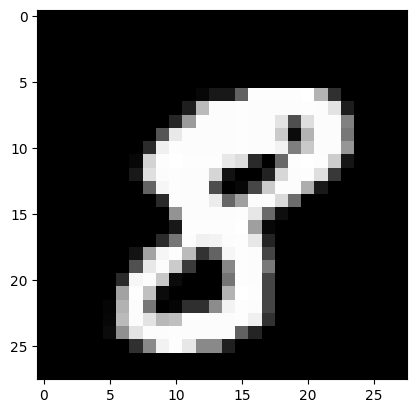

In [7]:
# 2.加载数据集
dataset = pd.read_csv("2.测试数据/data/train.csv")
# 测试图像
digit = dataset.iloc[10, 1:].values
plt.imshow(digit.reshape(28, 28), cmap="gray")

In [8]:
# 3.划分数据集
X = dataset.iloc[:, 1:]
y = dataset.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(29400, 784) (12600, 784) (29400,) (12600,)


In [11]:
# 4.特征工程-归一化
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# 5.模型定义及训练
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
print("训练集得分：", model.score(X_train, y_train))

训练集得分： 0.9473809523809524
